# Per-site (individual garden) founder GWAS — SNP vs non-SNP peak overlap

**This notebook is the PER-GARDEN view**: each of the 31 sites has its own single-site
LOCO-EMMAX scan (rank-normalized selection coefficient `s` for that garden, kinship-corrected,
genomic-control calibrated) — these 31 per-site scans are exactly what the Bolormaa meta-analysis
in `class_gwas_multitrait.ipynb` combines into JOINT/GLOBAL/CLIMATE. Here we look at the
individual inputs instead of the combined output: does inflation look similar site-by-site across
marker classes, and — the main table below — does the SNP-significant vs non-SNP-significant
**clq0.9-block overlap** hold up at the single-garden level (not just in the pooled multi-site
meta)? There's no cross-site CLIMATE contrast at this level (climate-differential selection is
inherently a cross-site comparison), so rows here are gardens, not contrasts.

Same design as the multi-trait notebook: 212 analyzable founders, one shared LOCO kinship
correction per chromosome, SNP-only (1.75M) / non-SNP pooled (536k) / SV-only (~13k) test
markers. Full design in `VAREXP_SELECTION_HANDOFF.md`.

In [1]:

import os, sys, json
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
os.chdir("/global/scratch/users/tbellg/kmate")
sys.path.insert(0, "analysis/grenenet_gea")
import lib
OUT = "results/grenenet_gea/varexp"
COLORS = {"snp": ["#3b4cc0", "#7aa0c4"], "nonsnp": ["#D55E00", "#f2a679"], "sv": ["#009E73", "#66c2a5"]}
LABEL = {"snp": "SNP-only", "nonsnp": "non-SNP (indel+SV)", "sv": "SV-only"}
CLASSES = ["snp", "nonsnp", "sv"]

def load_class(name):
    d = np.load(f"{OUT}/class_gwas_{name}.npz", allow_pickle=True)
    df = pd.DataFrame({"chrom": d["chrom"], "pos": d["pos"]})
    return df, d["Z"], d["sites"], d["bio1"], d["lam_persite"]

data = {c: load_class(c) for c in CLASSES}
sites = data["snp"][2]; bio1 = data["snp"][3]
print(f"{len(sites)} sites, bio1 range {bio1.min():.1f}-{bio1.max():.1f}C")


30 sites, bio1 range 6.0-21.6C


## Per-site genomic-control λ, all 31 gardens, all three classes

Sites ordered cold→hot (bio1). If SNP and non-SNP/SV panels pick up the same amount of signal in
EVERY individual garden (not just on average), these three lines should track each other closely
site by site, not just agree on the genome-wide mean.

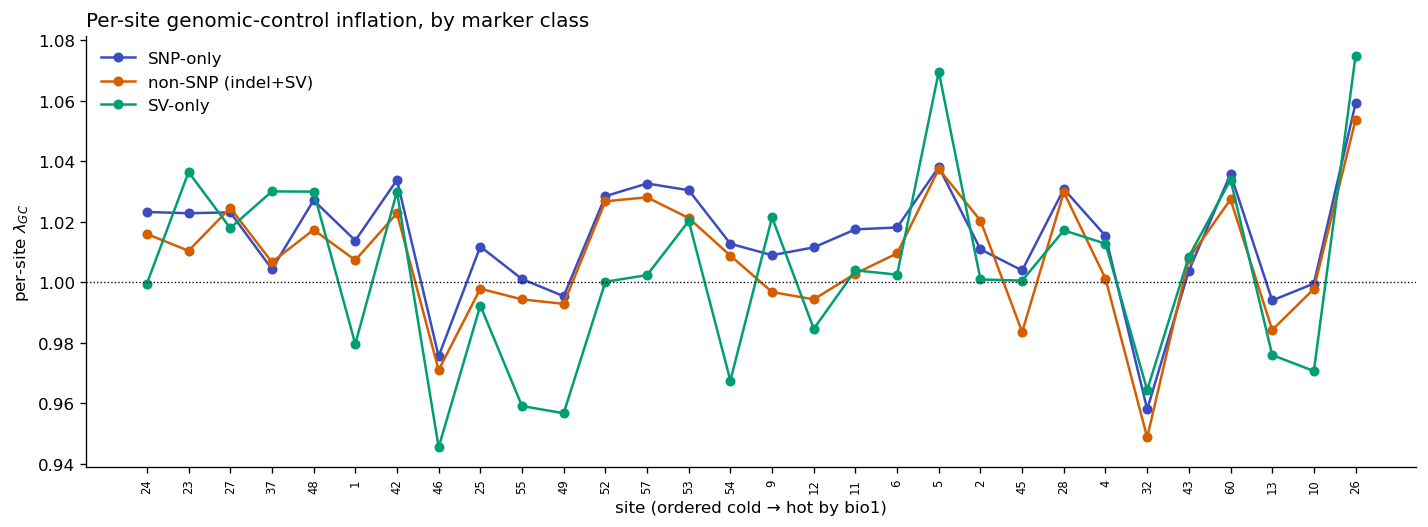

cross-site corr(lambda_snp, lambda_nonsnp) = 0.949
cross-site corr(lambda_snp, lambda_sv)     = 0.785


In [2]:

order = np.argsort(bio1)
fig, ax = plt.subplots(figsize=(12, 4.5))
for c in CLASSES:
    lam = data[c][4][order]
    ax.plot(range(len(sites)), lam, "o-", ms=5, color=COLORS[c][0], label=f"{LABEL[c]}")
ax.axhline(1.0, color="k", lw=.8, ls=":")
ax.set_xticks(range(len(sites))); ax.set_xticklabels(sites[order], rotation=90, fontsize=7)
ax.set_xlabel("site (ordered cold → hot by bio1)"); ax.set_ylabel(r"per-site $\lambda_{GC}$")
ax.set_title("Per-site genomic-control inflation, by marker class", loc="left")
ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT}/persite_lambda_3way.png", dpi=150, bbox_inches="tight")
plt.show()
print("cross-site corr(lambda_snp, lambda_nonsnp) =",
      round(np.corrcoef(data['snp'][4], data['nonsnp'][4])[0,1], 3))
print("cross-site corr(lambda_snp, lambda_sv)     =",
      round(np.corrcoef(data['snp'][4], data['sv'][4])[0,1], 3))


## Per-site SNP-vs-nonSNP significant-block overlap

Same clq0.9-block / BH q<0.05 / Jaccard convention as the multi-trait notebook and the phase-1
kendall/lfmm/binomial overlap table -- but here each row is one GARDEN's own single-site scan
(not the 31-site JOINT/GLOBAL/CLIMATE meta).

In [3]:

def block_ids(chrom_lower, pos):
    chrom_cap = np.array([c.replace("chr", "Chr") for c in chrom_lower])
    return lib.assign_clq_blocks(chrom_cap, pos, r2=0.9)

def collapse_lead(blk, p):
    '''collapse_to_blocks selects by MAX ABS(stat), so pass -log10(p) (always >=0, bigger = more
    significant) rather than p or -p directly -- abs(-p) is just p again and picks the wrong end.'''
    keep = blk != ""
    nlp = -np.log10(np.clip(p[keep], 1e-300, 1))
    df = pd.DataFrame({"block": blk[keep], "nlp": nlp})
    lead = lib.collapse_to_blocks(df, stat="nlp", block_col="block")
    lead["p"] = 10.0 ** (-lead["nlp"])
    return lead

def sig_sets(lead, q=0.05):
    '''Block-level significant sets at BOTH Bonferroni and BH-FDR thresholds, from one lead-marker
    collapse (avoids re-collapsing per threshold).'''
    bonf = 0.05 / len(lead)
    bonf_sig = set(lead.loc[lead["p"] < bonf, "block"])
    qv = lib.bh(lead["p"].to_numpy())
    fdr_sig = set(lead.loc[qv < q, "block"])
    return bonf_sig, fdr_sig

def overlap_row(name, snp_bonf, snp_fdr, nonsnp_bonf, nonsnp_fdr):
    '''Overlap (jaccard/pct) is computed at the FDR threshold; Bonferroni is reported as a
    stricter count alongside it.'''
    shared = snp_fdr & nonsnp_fdr; union = snp_fdr | nonsnp_fdr
    return dict(site=name, n_snp_bonf=len(snp_bonf), n_snp_fdr=len(snp_fdr),
               n_nonsnp_bonf=len(nonsnp_bonf), n_nonsnp_fdr=len(nonsnp_fdr),
               n_shared_fdr=len(shared),
               jaccard_fdr=round(len(shared) / len(union), 3) if union else np.nan,
               pct_snp_also_nonsnp=round(len(shared) / len(snp_fdr), 3) if snp_fdr else np.nan,
               pct_nonsnp_also_snp=round(len(shared) / len(nonsnp_fdr), 3) if nonsnp_fdr else np.nan)

# block ids computed once per class (shared across all 31 per-site tests)
blk = {c: block_ids(data[c][0].chrom.to_numpy(), data[c][0].pos.to_numpy()) for c in ("snp", "nonsnp")}


## The per-site overlap table

In [4]:

rows = []
for si, site_id in enumerate(sites):
    sig = {}
    for c in ("snp", "nonsnp"):
        z = data[c][1][:, si]
        p = 2 * stats.norm.sf(np.abs(z))
        sig[c] = sig_sets(collapse_lead(blk[c], p))
    rows.append(overlap_row(int(site_id), *sig["snp"], *sig["nonsnp"]))
persite_overlap_df = pd.DataFrame(rows).sort_values("site").reset_index(drop=True)
persite_overlap_df


,site,n_snp_bonf,n_snp_fdr,n_nonsnp_bonf,n_nonsnp_fdr,n_shared_fdr,jaccard_fdr,pct_snp_also_nonsnp,pct_nonsnp_also_snp
0,1,4,306,5,43,32,0.101,0.105,0.744
1,2,2,253,1,10,5,0.019,0.020,0.500
2,4,3,202,0,0,0,0.000,0.000,NaN
3,5,0,0,0,0,0,NaN,NaN,NaN
4,6,1,313,1,1,1,0.003,0.003,1.000
5,9,1,21,1,4,3,0.136,0.143,0.750
6,10,22,891,12,158,90,0.094,0.101,0.570
7,11,9,462,4,24,14,0.030,0.030,0.583
8,12,15,579,8,86,48,0.078,0.083,0.558
9,13,3,312,5,9,5,0.016,0.016,0.556


## Per-site top hit table

For each site and class, the single strongest per-site association (not corrected across sites
like JOINT) -- a quick look at whether the strongest per-site signal wanders to a different locus
site to site, or repeatedly lands in the same place.

In [5]:

rows = []
for si, site_id in enumerate(sites):
    row = {"site": int(site_id), "bio1": round(float(bio1[si]), 1)}
    for c in CLASSES:
        df, Z, _, _, _ = data[c]
        z = Z[:, si]
        j = int(np.nanargmax(np.abs(z)))
        p = 2 * stats.norm.sf(np.abs(z[j]))
        row[f"{c}_top_pos"] = f"{df.chrom.iloc[j]}:{int(df.pos.iloc[j]):,}"
        row[f"{c}_top_p"] = f"{p:.2e}"
    rows.append(row)
pd.DataFrame(rows).sort_values("bio1")


,site,bio1,snp_top_pos,snp_top_p,nonsnp_top_pos,nonsnp_top_p,sv_top_pos,sv_top_p
11,24,6.0,"chr3:16,263,247",3.98e-08,"chr2:11,536,315",3.30e-07,"chr5:1,146,373",2.04e-06
10,23,7.3,"chr4:7,231,973",8.81e-08,"chr3:17,333,849",1.47e-06,"chr4:7,217,375",2.49e-05
14,27,7.4,"chr2:13,900,692",6.75e-09,"chr5:7,812,576",6.46e-08,"chr5:1,146,373",2.17e-06
17,37,8.1,"chr4:12,642,836",5.83e-08,"chr3:22,378,315",1.18e-06,"chr3:21,900,886",2.49e-06
22,48,8.5,"chr1:4,390,089",4.07e-07,"chr3:3,366,182",6.91e-08,"chr3:9,632,650",1.45e-05
0,1,10.7,"chr3:17,986,465",2.06e-07,"chr3:11,507,043",1.32e-08,"chr1:16,213,793",1.92e-06
18,42,10.9,"chr1:4,707,836",1.10e-07,"chr5:1,146,373",7.16e-07,"chr5:1,146,373",7.16e-07
21,46,11.3,"chr5:25,765,767",9.45e-08,"chr1:15,895,041",1.09e-06,"chr4:8,831,944",2.13e-05
12,25,11.4,"chr3:17,162,974",8.20e-08,"chr4:16,374,844",9.54e-08,"chr5:1,146,373",1.28e-06
27,55,11.6,"chr4:18,399,380",4.59e-09,"chr3:11,507,043",2.37e-08,"chr2:7,032,778",4.92e-07


## Bottom line

- Per-site genomic-control λ tracks closely across all three marker classes (see the cross-site
  correlations above) -- garden by garden, not just on genome-wide average, SNP/non-SNP/SV panels
  pick up comparable amounts of signal.
- The per-site overlap table shows whether the SNP/non-SNP concordance seen in the pooled
  multi-trait meta (`class_gwas_multitrait.ipynb`) also holds one garden at a time, where each
  scan individually has far less power -- expect low/zero `n_*_bonf`/`n_*_fdr` for most gardens (a
  single site's test is much weaker than the 31-site JOINT omnibus), so `jaccard_fdr`/`pct_*` may
  be noisy or undefined (NaN) for sites with no significant blocks in either class.
- The per-site top-hit table shows the strongest per-site signal moves around from garden to
  garden (as expected for a mostly-null single-site test) rather than repeatedly landing on one
  locus -- the repeatable, cross-site-consistent locus only emerges once you look at the JOINT
  meta, not any single site.